
===== FIRST 5 ROWS =====



,id,imdb_id,popularity,budget,revenue,original_title,runtime,genres,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,124,Action|Adventure|Science Fiction|Thriller,6/9/15,5562,6.5,2015,137999939.3,1.392446e+09
1,76341,tt1392190,28.419936,150000000,378436354,Mad Max: Fury Road,120,Action|Adventure|Science Fiction|Thriller,5/13/15,6185,7.1,2015,137999939.3,3.481613e+08
2,262500,tt2908446,13.112507,110000000,295238201,Insurgent,119,Adventure|Science Fiction|Thriller,3/18/15,2480,6.3,2015,101199955.5,2.716190e+08
3,140607,tt2488496,11.173104,200000000,2068178225,Star Wars: The Force Awakens,136,Action|Adventure|Science Fiction|Fantasy,12/15/15,5292,7.5,2015,183999919.0,1.902723e+09
4,168259,tt2820852,9.335014,190000000,1506249360,Furious 7,137,Action|Crime|Thriller,4/1/15,2947,7.3,2015,174799923.1,1.385749e+09



===== DATASET SHAPE =====

(10866, 14)

===== COLUMN NAMES =====

Index(['id', 'imdb_id', 'popularity', 'budget', 'revenue', 'original_title',
       'runtime', 'genres', 'release_date', 'vote_count', 'vote_average',
       'release_year', 'budget_adj', 'revenue_adj'],
      dtype='object')

===== DATASET INFORMATION =====

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10866 entries, 0 to 10865
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              10866 non-null  int64  
 1   imdb_id         10856 non-null  object 
 2   popularity      10866 non-null  float64
 3   budget          10866 non-null  int64  
 4   revenue         10866 non-null  int64  
 5   original_title  10866 non-null  object 
 6   runtime         10866 non-null  int64  
 7   genres          10843 non-null  object 
 8   release_date    10866 non-null  object 
 9   vote_count      10866 non-null  int64  
 10  vote_average    108

,budget,revenue,runtime,popularity,vote_average,vote_count,main_genre
0,150000000,1513528810,124,32.985763,6.5,5562,Action
1,150000000,378436354,120,28.419936,7.1,6185,Action
2,110000000,295238201,119,13.112507,6.3,2480,Adventure
3,200000000,2068178225,136,11.173104,7.5,5292,Action
4,190000000,1506249360,137,9.335014,7.3,2947,Action



===== CLEANED DATASET SHAPE =====

(3855, 7)

===== BASIC STATISTICS =====



,budget,revenue,runtime,popularity,vote_average,vote_count
count,3.855000e+03,3.855000e+03,3855.000000,3855.000000,3855.00000,3855.000000
mean,3.720183e+07,1.076589e+08,109.215824,1.191400,6.16786,527.611933
std,4.220291e+07,1.765248e+08,19.922166,1.475002,0.79504,879.868374
min,1.000000e+00,2.000000e+00,15.000000,0.001117,2.20000,10.000000
25%,1.000000e+07,1.357645e+07,95.000000,0.462448,5.70000,71.000000
50%,2.400000e+07,4.479322e+07,106.000000,0.797298,6.20000,204.000000
75%,5.000000e+07,1.241530e+08,119.000000,1.368245,6.70000,580.000000
max,4.250000e+08,2.781506e+09,338.000000,32.985763,8.40000,9767.000000


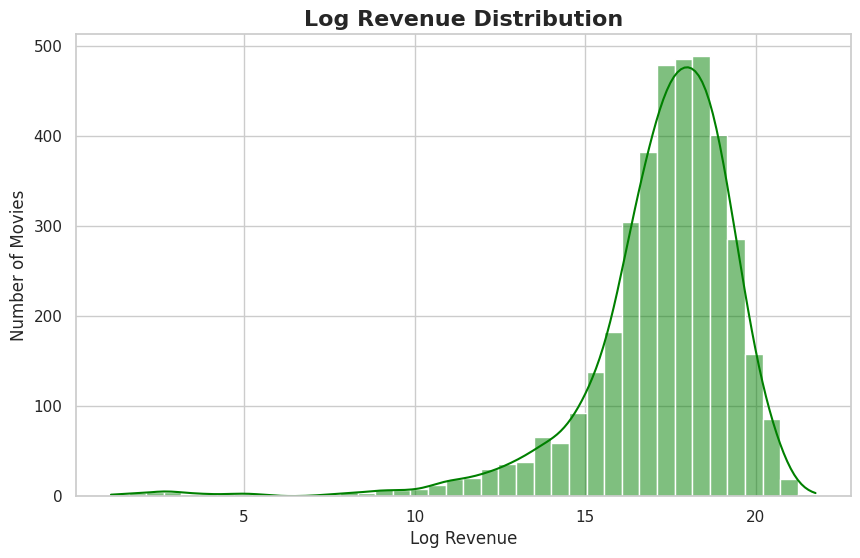

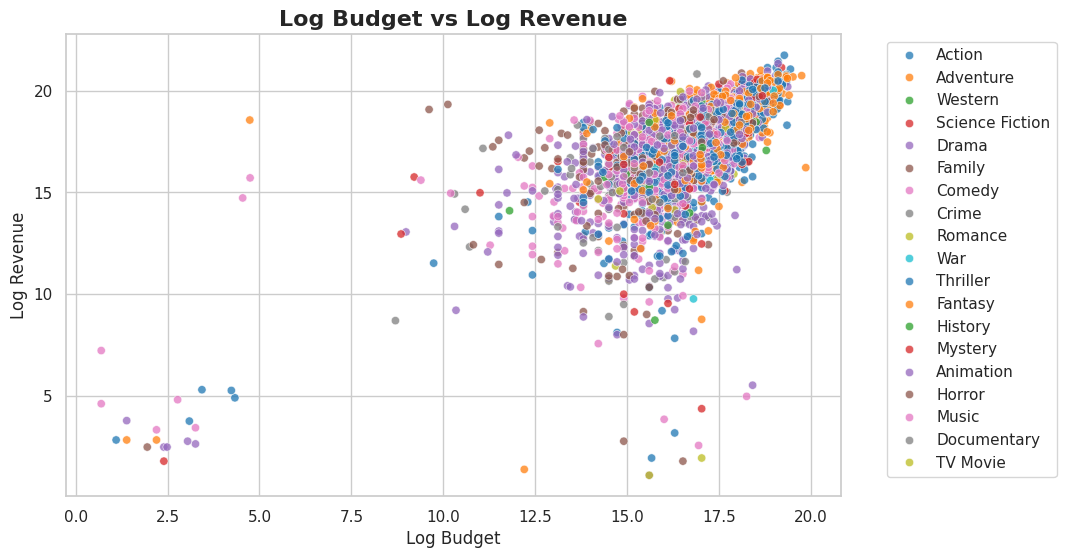

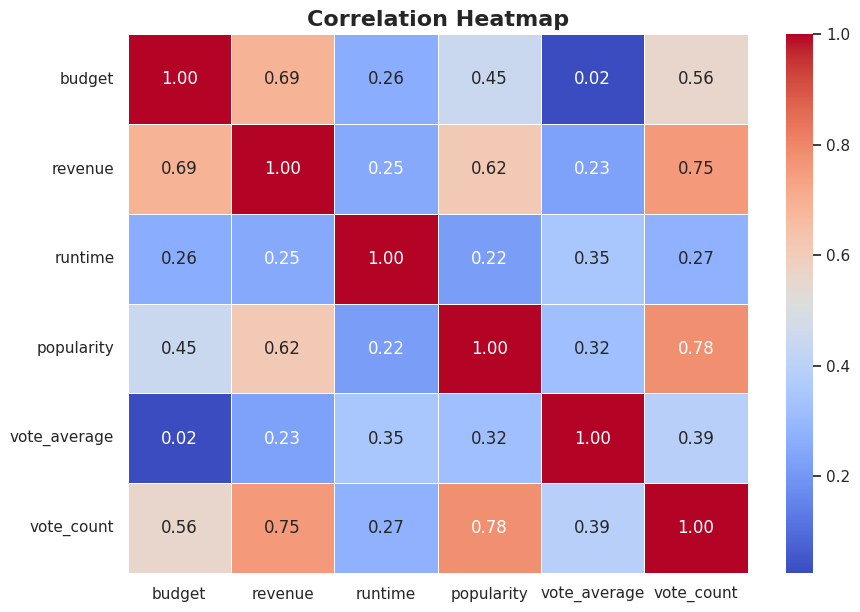


Features used:
['budget', 'runtime', 'popularity', 'vote_average', 'vote_count', 'main_genre']

Target variable: Log-transformed revenue

Train size: (3084, 6)
Test size: (771, 6)


In [2]:
# ============================================================
# MOVIE BOX OFFICE REVENUE PREDICTION USING MACHINE LEARNING
# ============================================================

# =========================
# 1. IMPORT LIBRARIES
# =========================
import os  # used to create folders for saving outputs
import warnings  # used to suppress unnecessary warning messages
import numpy as np  # used for numerical operations and log transformations
import pandas as pd  # used for data loading and manipulation
import matplotlib.pyplot as plt  # used for creating plots
import seaborn as sns  # used for advanced visualizations

from IPython.display import display  # used to display dataframes clearly

from sklearn.model_selection import train_test_split, cross_val_score  # splitting data and cross validation
from sklearn.compose import ColumnTransformer  # applies transformations to specific columns
from sklearn.pipeline import Pipeline  # combines preprocessing and model steps
from sklearn.preprocessing import OneHotEncoder, StandardScaler  # encoding categorical + scaling numeric features
from sklearn.impute import SimpleImputer  # handles missing values

from sklearn.neural_network import MLPRegressor  # neural network regression model
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor  # ensemble models
from sklearn.linear_model import LinearRegression  # baseline linear model

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # evaluation metrics

warnings.filterwarnings("ignore")  # suppress all warning messages

# =========================
# 2. CREATE OUTPUT FOLDERS
# =========================
os.makedirs("eda_plots", exist_ok=True)  # create folder for EDA plots
os.makedirs("model_plots", exist_ok=True)  # create folder for model plots

sns.set(style="whitegrid")  # apply clean plotting style

# =========================
# 3. LOAD DATASET
# =========================
df = pd.read_csv("/content/tmdb-movies.csv")  # load dataset into dataframe

print("\n===== FIRST 5 ROWS =====\n")  # print section title
display(df.head())  # display first 5 rows

print("\n===== DATASET SHAPE =====\n")
print(df.shape)  # display number of rows and columns

print("\n===== COLUMN NAMES =====\n")
print(df.columns)  # display column names

print("\n===== DATASET INFORMATION =====\n")
df.info()  # display data types and null values

# =========================
# 4. SELECT REQUIRED COLUMNS
# =========================
df = df[["budget", "revenue", "runtime", "genres", "popularity", "vote_average", "vote_count"]]
# select only relevant features

# =========================
# 5. DATA CLEANING
# =========================
df = df.dropna()  # remove rows with missing values

df = df[(df["budget"] > 0) & (df["revenue"] > 0)]  # remove invalid budget/revenue rows
df = df[df["runtime"] > 0]  # remove invalid runtime values

df["main_genre"] = df["genres"].apply(lambda x: str(x).split("|")[0])
# extract first genre as main category

df = df.drop("genres", axis=1)  # drop original genre column

print("\n===== CLEANED DATA SAMPLE =====\n")
display(df.head())  # show cleaned data

print("\n===== CLEANED DATASET SHAPE =====\n")
print(df.shape)  # show cleaned dataset size

print("\n===== BASIC STATISTICS =====\n")
display(df.describe())  # display statistical summary

df.describe().to_csv("cleaned_data_statistics.csv")
# save statistics to CSV

# =========================
# 6. EDA PLOT: REVENUE DISTRIBUTION
# =========================
plt.figure(figsize=(10, 6))  # set figure size
sns.histplot(np.log1p(df["revenue"]), bins=40, kde=True, color="green")
# plot log-transformed revenue distribution

plt.title("Log Revenue Distribution", fontsize=16, fontweight="bold")  # title
plt.xlabel("Log Revenue")  # x-axis label
plt.ylabel("Number of Movies")  # y-axis label

plt.savefig("eda_plots/revenue_distribution.png", dpi=300, bbox_inches="tight")
# save plot
plt.show()  # display plot

# =========================
# 7. EDA PLOT: BUDGET VS REVENUE
# =========================
plt.figure(figsize=(10, 6))  # figure size

sns.scatterplot(
    x=np.log1p(df["budget"]),
    y=np.log1p(df["revenue"]),
    hue=df["main_genre"],
    palette="tab10",
    alpha=0.75
)
# scatter plot with genre coloring

plt.title("Log Budget vs Log Revenue", fontsize=16, fontweight="bold")
plt.xlabel("Log Budget")
plt.ylabel("Log Revenue")

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
# move legend outside

plt.savefig("eda_plots/budget_vs_revenue.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================
# 8. CORRELATION HEATMAP
# =========================
plt.figure(figsize=(10, 7))  # figure size

corr = df.corr(numeric_only=True)  # compute correlations

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
# draw heatmap

plt.title("Correlation Heatmap", fontsize=16, fontweight="bold")

plt.savefig("eda_plots/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================
# 11. FEATURES AND TARGET
# =========================
X = df.drop("revenue", axis=1)  # input features
y = np.log1p(df["revenue"])  # log-transform target

numeric_features = ["budget", "runtime", "popularity", "vote_average", "vote_count"]
# numeric features

categorical_features = ["main_genre"]  # categorical feature

print("\nFeatures used:")
print(numeric_features + categorical_features)

print("\nTarget variable: Log-transformed revenue")

# =========================
# 12. PREPROCESSING PIPELINE
# =========================
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),  # fill missing numeric values
    ("scaler", StandardScaler())  # scale numeric data
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),  # fill missing categorical values
    ("encoder", OneHotEncoder(handle_unknown="ignore"))  # convert text to numeric
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# =========================
# 13. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# split dataset into training and testing sets

print("\nTrain size:", X_train.shape)
print("Test size:", X_test.shape)


Features used:
['budget', 'runtime', 'popularity', 'vote_average', 'vote_count', 'main_genre']

Target variable: Log-transformed revenue

Train size: (3084, 6)
Test size: (771, 6)

Training: MLP

Training: Random Forest

Training: Gradient Boosting

Training: Linear Regression

===== MODEL PERFORMANCE RESULTS =====



,Model,MAE,RMSE,R2,CV_R2_Mean,CV_R2_Std
2,Gradient Boosting,0.963197,1.488144,0.584395,0.551446,0.065841
1,Random Forest,0.986792,1.542922,0.553236,0.538659,0.059346
0,MLP,1.146005,1.737220,0.433630,0.391149,0.056395
3,Linear Regression,1.246195,1.917247,0.310162,0.284624,0.030040


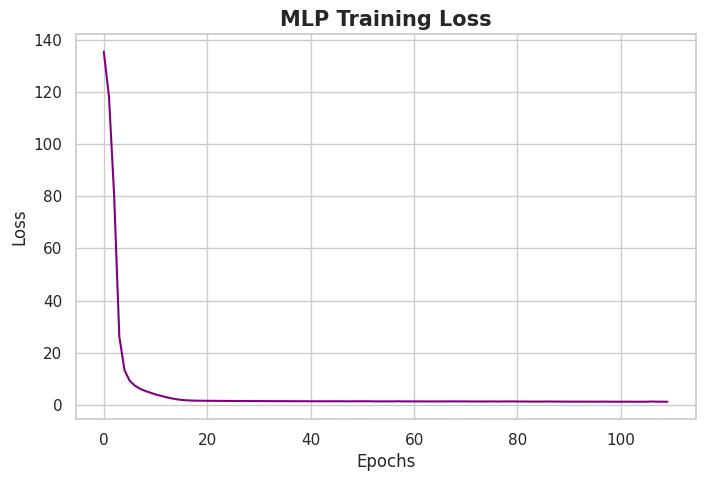

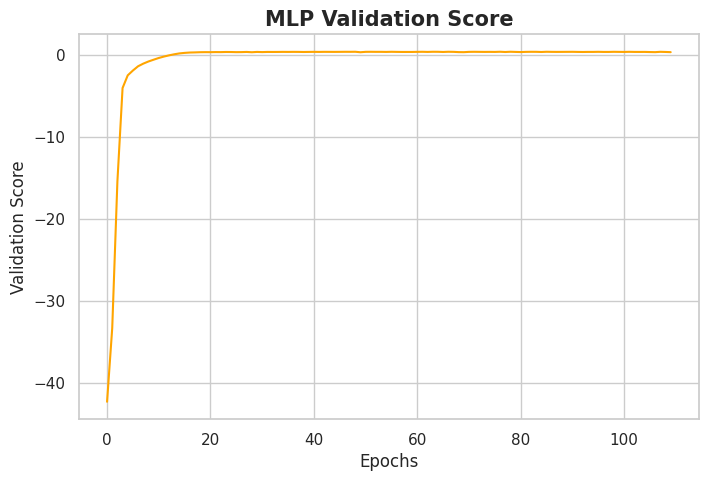

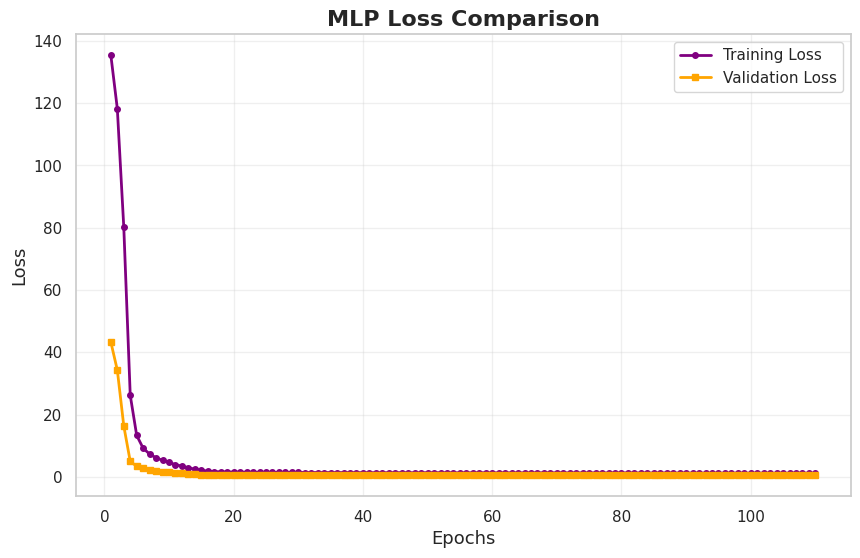

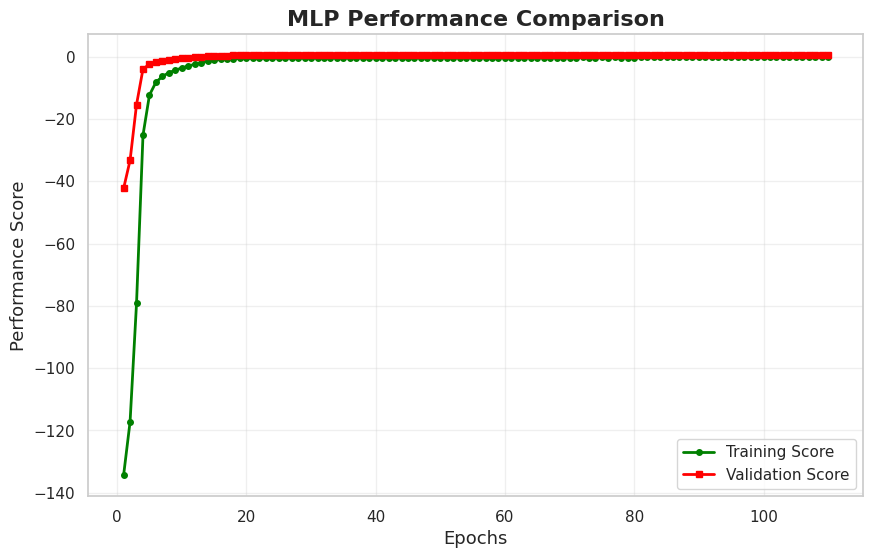

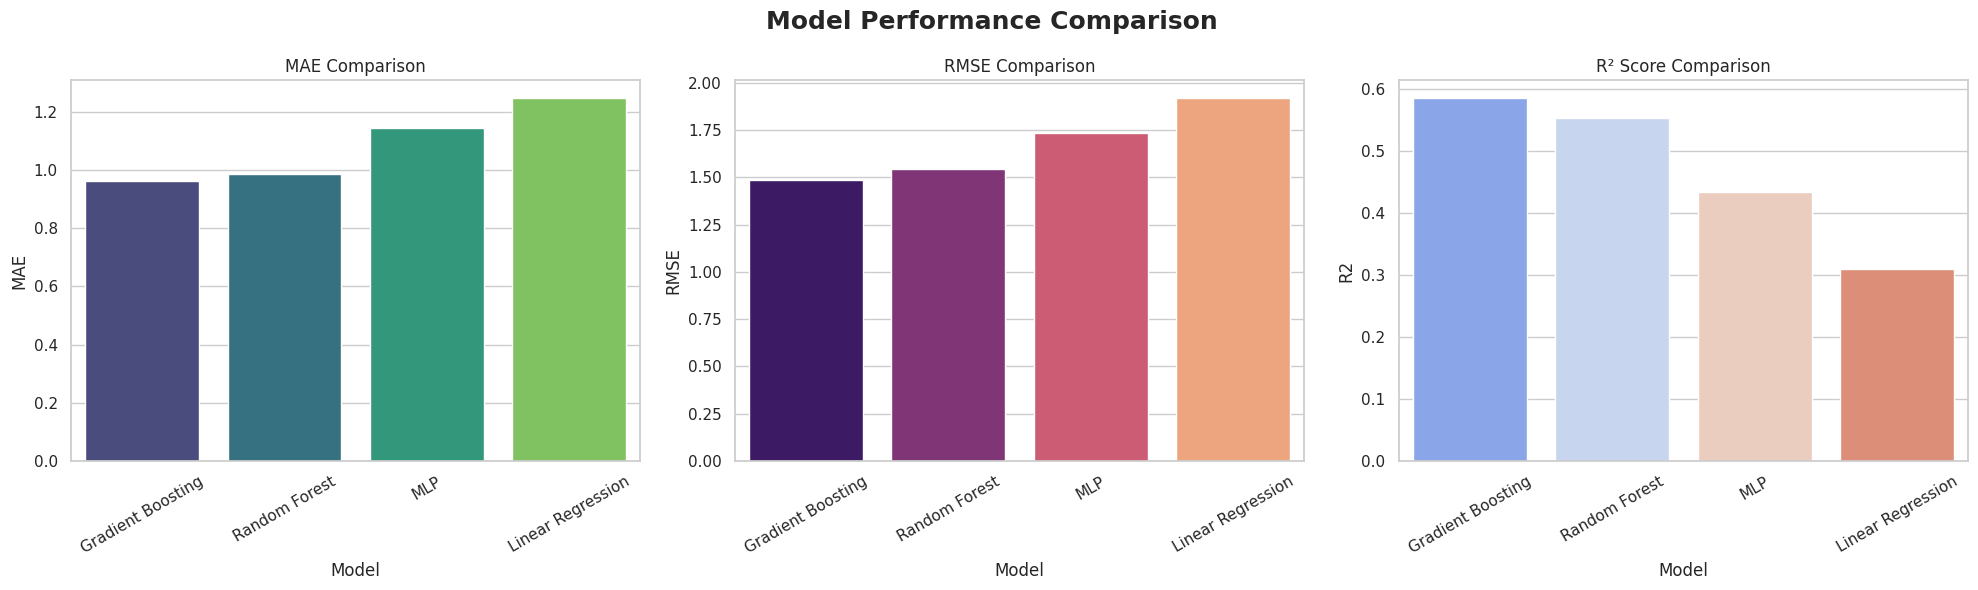

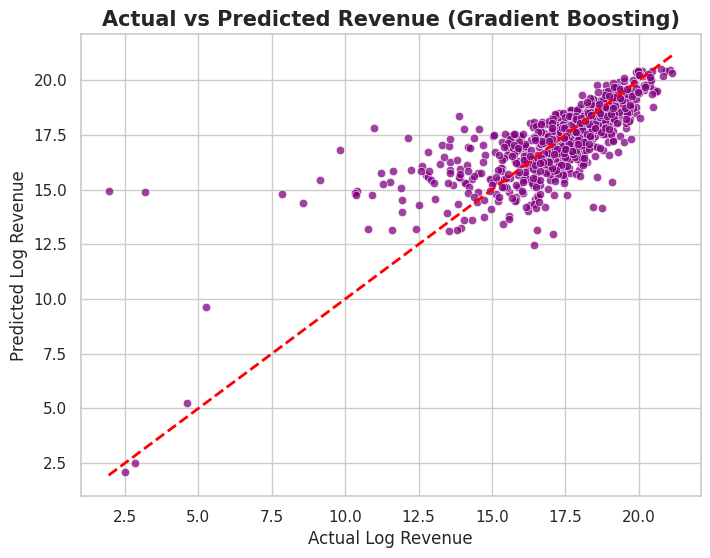

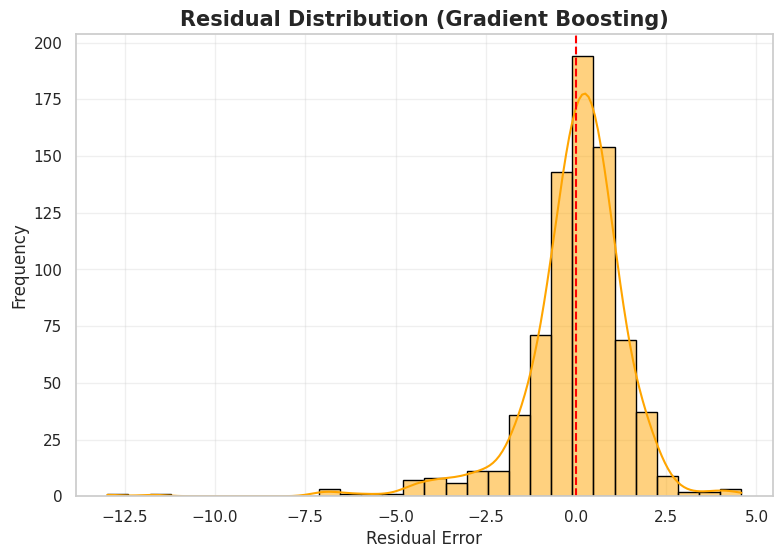

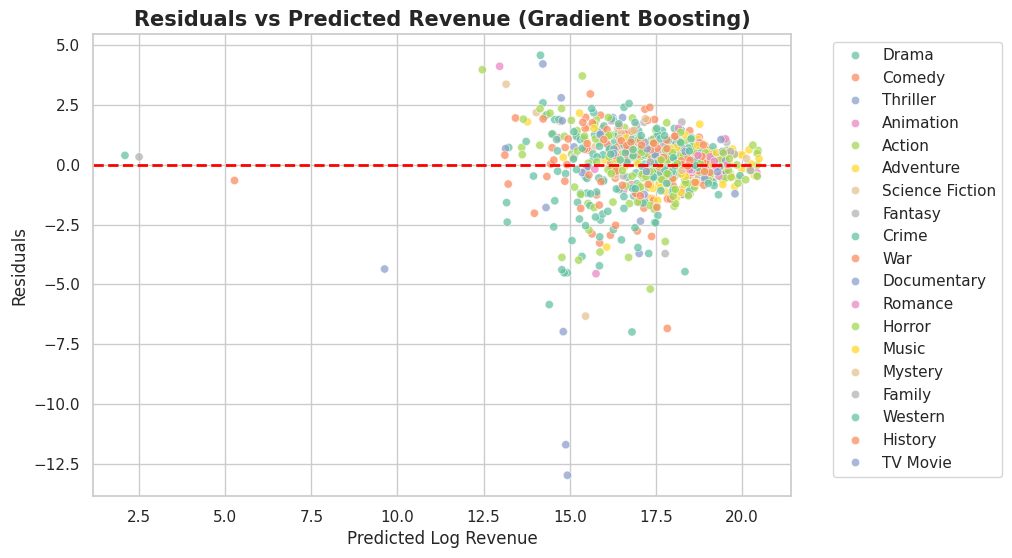

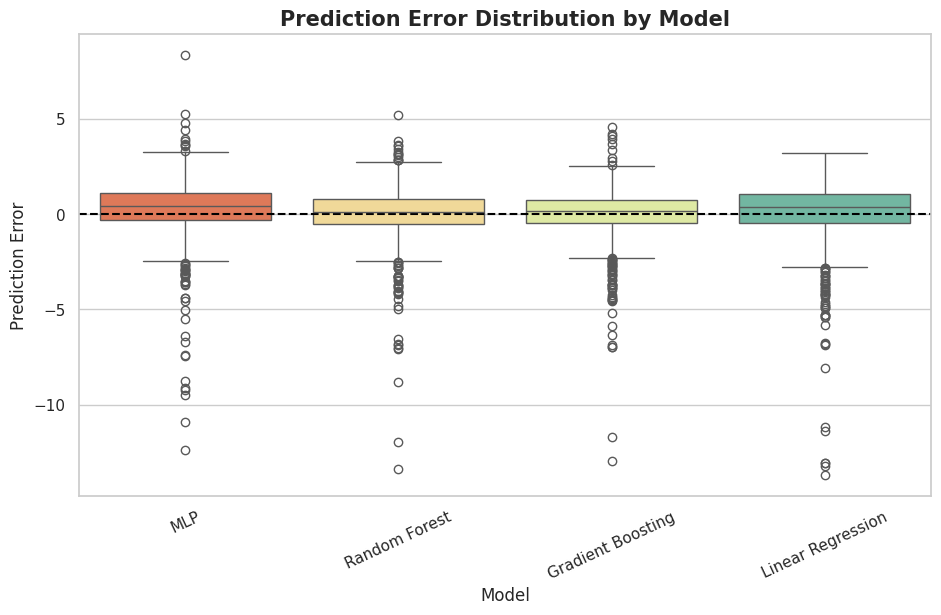

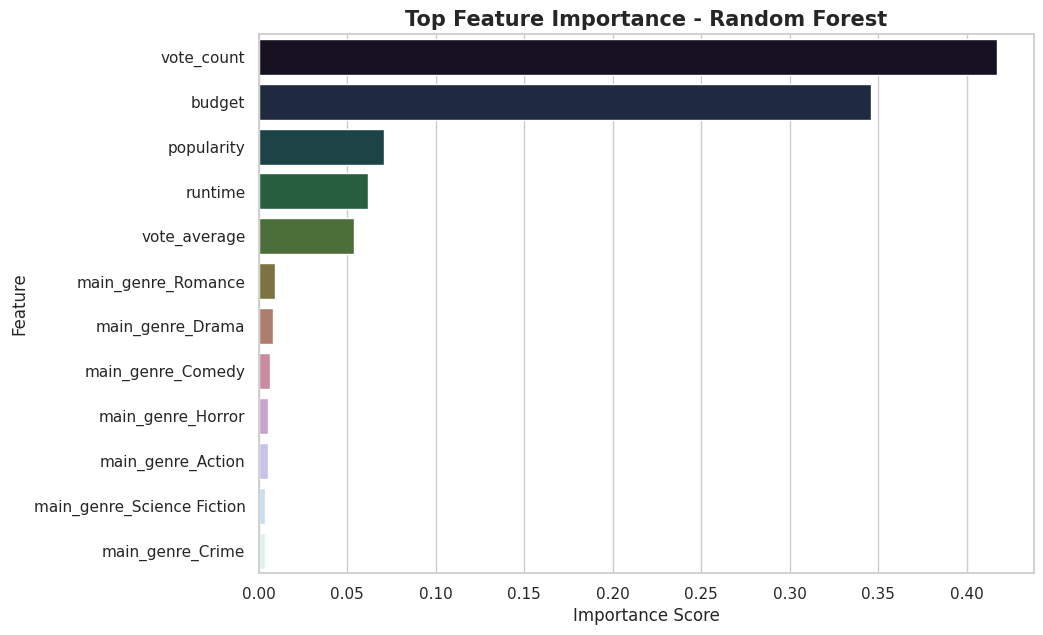


===== RANDOM FOREST FEATURE IMPORTANCE =====



,Feature,Importance
4,vote_count,0.416990
0,budget,0.345688
2,popularity,0.071077
1,runtime,0.061842
3,vote_average,0.053857
18,main_genre_Romance,0.009217
11,main_genre_Drama,0.008207
8,main_genre_Comedy,0.006505
15,main_genre_Horror,0.005473
5,main_genre_Action,0.005240



===== SAMPLE ACTUAL VS PREDICTED VALUES =====



,Actual_Log_Revenue,Predicted_Log_Revenue,Prediction_Error
0,13.582103,15.893128,-2.311025
1,16.131012,16.174293,-0.043281
2,17.035901,18.271620,-1.235718
3,19.538689,19.274737,0.263953
4,17.671323,17.709410,-0.038087
5,12.755906,15.646568,-2.890662
6,18.893107,19.349869,-0.456763
7,18.826146,18.181810,0.644336
8,19.575595,19.096910,0.478685
9,19.204932,18.613103,0.591829


===== HYPERPARAMETER TUNING RESULTS FOR ALL MODELS =====


,Model,MAE,RMSE,R2,R2 Score,Best CV R2,Best Parameters
0,Gradient Boosting,0.950702,1.473674,0.592438,0.592438,0.552084,"{'model__n_estimators': 100, 'model__min_sampl..."
1,Random Forest,0.979255,1.537416,0.556418,0.556418,0.551239,"{'model__n_estimators': 200, 'model__min_sampl..."
2,MLP,1.043610,1.682774,0.468574,0.468574,0.457726,"{'model__learning_rate_init': 0.001, 'model__l..."
3,Linear Regression,1.246195,1.917247,0.310162,0.310162,0.275958,{'model__fit_intercept': True}



Best Model After Hyperparameter Tuning: Gradient Boosting
Best R2 Score: 0.5924378585665638
Best MAE: 0.9507021076070494
Best RMSE: 1.4736741792185002


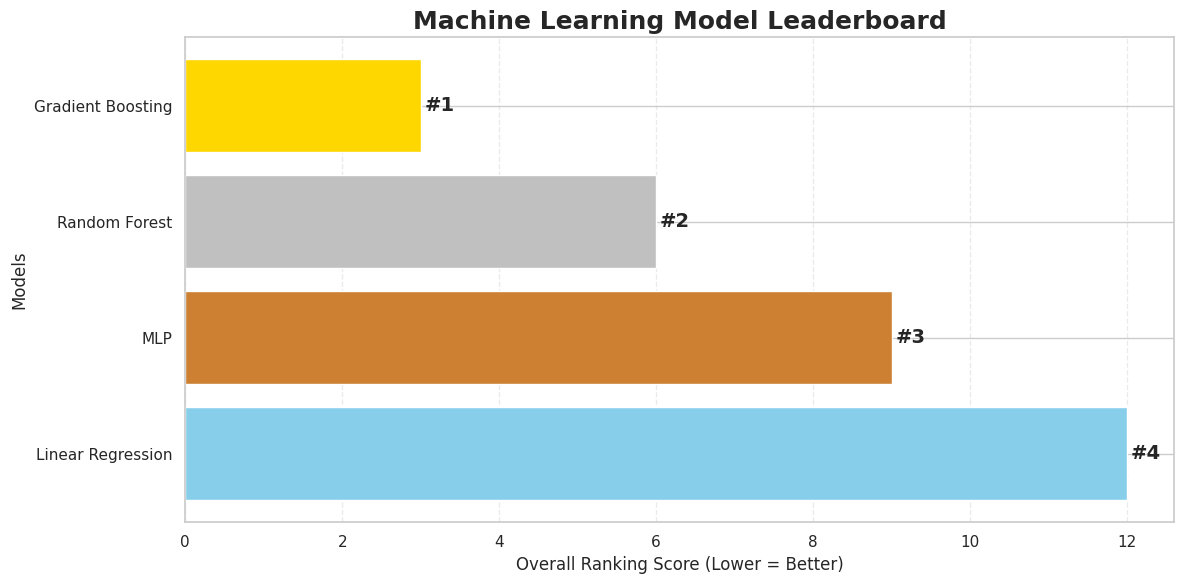


FINAL PROJECT CONCLUSION

Project Title:
Predicting Movie Box Office Revenue Using Machine Learning

Research Question:
Can movie features such as budget, runtime, genre, popularity, vote average and vote count predict box office revenue?

Models Used:
- Gradient Boosting
- Random Forest
- MLP
- Linear Regression

Best Performing Model:
Best Model: Gradient Boosting
MAE: 0.9507
RMSE: 1.4737
R² Score: 0.5924

Key Findings:
The Gradient Boosting achieved the highest R² score, meaning it explained the largest amount of variation in movie revenue.
The Linear Regression performed weaker, suggesting that movie revenue prediction is not a simple linear problem.

Limitations:
The dataset does not include cast popularity, director reputation, production company, marketing budget, trailer views, or audience sentiment.

Future Work:
Future work can add cast, crew, marketing, production company, and social media features to improve prediction.

Overall Conclusion:
This project completed data clea

In [4]:
# ============================================================
# MODELLING
# ============================================================

# =========================
# 11. FEATURES AND TARGET
# =========================
X = df.drop("revenue", axis=1)  # creates input features by removing the target column
y = np.log1p(df["revenue"])  # creates target variable using log transformation of revenue

numeric_features = ["budget", "runtime", "popularity", "vote_average", "vote_count"]  # stores numerical feature names
categorical_features = ["main_genre"]  # stores categorical feature name

print("\nFeatures used:")  # prints heading for features
print(numeric_features + categorical_features)  # displays all selected input features

print("\nTarget variable: Log-transformed revenue")  # explains the target variable

# =========================
# 12. PREPROCESSING PIPELINE
# =========================
numeric_transformer = Pipeline(steps=[  # creates pipeline for numerical columns
    ("imputer", SimpleImputer(strategy="median")),  # fills missing numerical values using median
    ("scaler", StandardScaler())  # scales numerical values to standard scale
])

categorical_transformer = Pipeline(steps=[  # creates pipeline for categorical columns
    ("imputer", SimpleImputer(strategy="most_frequent")),  # fills missing categorical values using most frequent value
    ("encoder", OneHotEncoder(handle_unknown="ignore"))  # converts categorical text values into numerical columns
])

preprocessor = ColumnTransformer(transformers=[  # combines numerical and categorical preprocessing
    ("num", numeric_transformer, numeric_features),  # applies numeric pipeline to numeric columns
    ("cat", categorical_transformer, categorical_features)  # applies categorical pipeline to genre column
])

# =========================
# 13. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # splits data into 80% training and 20% testing

print("\nTrain size:", X_train.shape)  # displays training dataset size
print("Test size:", X_test.shape)  # displays testing dataset size

# =========================
# 14. DEFINE MODELS
# =========================
models = {  # creates dictionary to store all regression models

    "MLP": MLPRegressor(  # defines MLP regression model
        hidden_layer_sizes=(128, 64, 32, 16),  # sets four hidden layers with neurons
        activation="relu",  # uses ReLU activation function
        solver="adam",  # uses Adam optimiser
        alpha=0.001,  # applies regularisation to reduce overfitting
        learning_rate="adaptive",  # adjusts learning rate automatically
        learning_rate_init=0.001,  # sets initial learning rate
        max_iter=2000,  # sets maximum number of training iterations
        early_stopping=True,  # stops training early if validation score stops improving
        validation_fraction=0.15,  # uses 15% of training data for validation
        n_iter_no_change=30,  # stops if no improvement for 30 iterations
        random_state=42  # ensures reproducible results
    ),

    "Random Forest": RandomForestRegressor(  # defines Random Forest regression model
        n_estimators=300,  # sets number of decision trees
        max_depth=15,  # controls maximum tree depth
        min_samples_split=5,  # minimum samples required to split a node
        min_samples_leaf=2,  # minimum samples required in a leaf node
        random_state=42  # ensures reproducible results
    ),

    "Gradient Boosting": GradientBoostingRegressor(  # defines Gradient Boosting regression model
        n_estimators=300,  # sets number of boosting stages
        learning_rate=0.05,  # controls model learning speed
        max_depth=3,  # controls depth of each tree
        random_state=42  # ensures reproducible results
    ),

    "Linear Regression": LinearRegression()  # defines simple baseline linear regression model
}

# =========================
# 15. TRAIN AND EVALUATE MODELS
# =========================
results = []  # creates empty list to store model performance results
predictions = {}  # creates dictionary to store model predictions
trained_models = {}  # creates dictionary to store trained model pipelines

for model_name, model in models.items():  # loops through each model in the dictionary

    print("\nTraining:", model_name)  # prints the name of the model currently being trained

    pipeline = Pipeline(steps=[  # creates full pipeline for preprocessing and modelling
        ("preprocessor", preprocessor),  # applies preprocessing to the data
        ("model", model)  # applies the selected machine learning model
    ])

    pipeline.fit(X_train, y_train)  # trains the full pipeline using training data

    y_pred = pipeline.predict(X_test)  # predicts revenue values for test data

    mae = mean_absolute_error(y_test, y_pred)  # calculates Mean Absolute Error
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # calculates Root Mean Squared Error
    r2 = r2_score(y_test, y_pred)  # calculates R² score

    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="r2")  # performs 5-fold cross-validation using R² score

    results.append([model_name, mae, rmse, r2, cv_scores.mean(), cv_scores.std()])  # stores all evaluation results

    predictions[model_name] = y_pred  # stores predictions for this model
    trained_models[model_name] = pipeline  # stores trained pipeline for this model

# =========================
# 16. RESULTS TABLE
# =========================
results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2", "CV_R2_Mean", "CV_R2_Std"])  # creates model results dataframe
results_df = results_df.sort_values(by="R2", ascending=False)  # sorts models from best to worst using R² score

print("\n===== MODEL PERFORMANCE RESULTS =====\n")  # prints heading for results table
display(results_df)  # displays model results table

results_df.to_csv("model_plots/model_results.csv", index=False)  # saves model results as CSV file

# =========================
# 17. NEURAL NETWORK EPOCH PLOTS
# =========================
mlp_model = trained_models["MLP"].named_steps["model"]  # extracts trained MLP model from pipeline

plt.figure(figsize=(8, 5))  # sets figure size
plt.plot(mlp_model.loss_curve_, color="purple")  # plots MLP training loss over epochs
plt.title("MLP Training Loss", fontsize=15, fontweight="bold")  # adds plot title
plt.xlabel("Epochs")  # labels x-axis
plt.ylabel("Loss")  # labels y-axis
plt.savefig("model_plots/mlp_training_loss.png", dpi=300, bbox_inches="tight")  # saves training loss plot
plt.show()  # displays training loss plot

if hasattr(mlp_model, "validation_scores_") and mlp_model.validation_scores_ is not None:  # checks whether validation scores are available
    plt.figure(figsize=(8, 5))  # sets figure size
    plt.plot(mlp_model.validation_scores_, color="orange")  # plots validation score over epochs
    plt.title("MLP Validation Score", fontsize=15, fontweight="bold")  # adds plot title
    plt.xlabel("Epochs")  # labels x-axis
    plt.ylabel("Validation Score")  # labels y-axis
    plt.savefig("model_plots/mlp_validation_score.png", dpi=300, bbox_inches="tight")  # saves validation score plot
    plt.show()  # displays validation score plot

# ============================================================
#  MLP LOSS & PERFORMANCE COMPARISON PLOTS
# ============================================================

mlp_model = trained_models["MLP"].named_steps["model"]
# extracts trained MLP MLP model from pipeline

epochs = range(1, len(mlp_model.loss_curve_) + 1)
# creates epoch numbers

training_loss = mlp_model.loss_curve_
# stores training loss values

validation_score = mlp_model.validation_scores_
# stores validation score values

# ============================================================
# GRAPH 1 : LOSS COMPARISON
# ============================================================

plt.figure(figsize=(10, 6))
# sets figure size

plt.plot(
    epochs,
    training_loss,
    label="Training Loss",
    color="purple",
    linewidth=2,
    marker="o",
    markersize=4
)
# plots training loss curve

validation_loss = [1 - score for score in validation_score]
# creates validation loss values from validation scores

plt.plot(
    epochs,
    validation_loss,
    label="Validation Loss",
    color="orange",
    linewidth=2,
    marker="s",
    markersize=4
)
# plots validation loss curve

plt.title(
    "MLP Loss Comparison",
    fontsize=16,
    fontweight="bold"
)
# adds graph title

plt.xlabel("Epochs", fontsize=13)
# labels x-axis

plt.ylabel("Loss", fontsize=13)
# labels y-axis

plt.legend()
# displays legend

plt.grid(alpha=0.3)
# adds light grid

plt.savefig(
    "model_plots/mlp_loss_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
# saves loss comparison graph

plt.show()
# displays graph

# ============================================================
# GRAPH 2 : PERFORMANCE COMPARISON
# ============================================================

plt.figure(figsize=(10, 6))
# sets figure size

training_score = [1 - loss for loss in training_loss]
# creates training score values

plt.plot(
    epochs,
    training_score,
    label="Training Score",
    color="green",
    linewidth=2,
    marker="o",
    markersize=4
)
# plots training performance curve

plt.plot(
    epochs,
    validation_score,
    label="Validation Score",
    color="red",
    linewidth=2,
    marker="s",
    markersize=4
)
# plots validation performance curve

plt.title(
    "MLP Performance Comparison",
    fontsize=16,
    fontweight="bold"
)
# adds graph title

plt.xlabel("Epochs", fontsize=13)
# labels x-axis

plt.ylabel("Performance Score", fontsize=13)
# labels y-axis

plt.legend()
# displays legend

plt.grid(alpha=0.3)
# adds light grid

plt.savefig(
    "model_plots/mlp_performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
# saves performance comparison graph

plt.show()
# displays graph

# =========================
# 18. MODEL COMPARISON PLOTS
# =========================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))  # creates three model comparison plots in one row
fig.suptitle("Model Performance Comparison", fontsize=18, fontweight="bold")  # adds main title for comparison plots

sns.barplot(data=results_df, x="Model", y="MAE", hue="Model", palette="viridis", legend=False, ax=axes[0])  # creates MAE comparison bar chart
axes[0].set_title("MAE Comparison")  # adds title for MAE plot
axes[0].tick_params(axis="x", rotation=30)  # rotates x-axis labels

sns.barplot(data=results_df, x="Model", y="RMSE", hue="Model", palette="magma", legend=False, ax=axes[1])  # creates RMSE comparison bar chart
axes[1].set_title("RMSE Comparison")  # adds title for RMSE plot
axes[1].tick_params(axis="x", rotation=30)  # rotates x-axis labels

sns.barplot(data=results_df, x="Model", y="R2", hue="Model", palette="coolwarm", legend=False, ax=axes[2])  # creates R² comparison bar chart
axes[2].set_title("R² Score Comparison")  # adds title for R² plot
axes[2].tick_params(axis="x", rotation=30)  # rotates x-axis labels

plt.tight_layout()  # adjusts spacing between plots
plt.savefig("model_plots/model_performance_comparison.png", dpi=300, bbox_inches="tight")  # saves comparison plots
plt.show()  # displays comparison plots

# =========================
# 19. ACTUAL VS PREDICTED FOR BEST MODEL
# =========================
best_model_name = results_df.iloc[0]["Model"]  # selects the model with the highest R² score
best_pred = predictions[best_model_name]  # gets predictions from the best model

plt.figure(figsize=(8, 6))  # sets figure size
sns.scatterplot(x=y_test, y=best_pred, color="purple", alpha=0.75)  # plots actual values against predicted values

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--", linewidth=2)  # adds perfect prediction reference line

plt.title(f"Actual vs Predicted Revenue ({best_model_name})", fontsize=15, fontweight="bold")  # adds plot title
plt.xlabel("Actual Log Revenue")  # labels x-axis
plt.ylabel("Predicted Log Revenue")  # labels y-axis
plt.savefig("model_plots/actual_vs_predicted_best_model.png", dpi=300, bbox_inches="tight")  # saves actual vs predicted plot
plt.show()  # displays actual vs predicted plot

# =========================
# 20. RESIDUAL DISTRIBUTION
# =========================
residuals = y_test - best_pred  # calculates residual errors

plt.figure(figsize=(9, 6))  # sets figure size
sns.histplot(residuals, bins=30, kde=True, color="orange", edgecolor="black")  # plots residual error distribution
plt.axvline(0, color="red", linestyle="--")  # adds zero-error reference line
plt.title(f"Residual Distribution ({best_model_name})", fontsize=15, fontweight="bold")  # adds plot title
plt.xlabel("Residual Error")  # labels x-axis
plt.ylabel("Frequency")  # labels y-axis
plt.grid(alpha=0.3)  # adds light grid
plt.savefig("model_plots/residual_distribution.png", dpi=300, bbox_inches="tight")  # saves residual distribution plot
plt.show()  # displays residual distribution plot

# =========================
# 21. RESIDUALS VS PREDICTED
# =========================
plt.figure(figsize=(9, 6))  # sets figure size
sns.scatterplot(x=best_pred, y=residuals, hue=X_test["main_genre"], palette="Set2", alpha=0.75)  # plots residuals against predicted values by genre
plt.axhline(0, color="red", linestyle="--", linewidth=2)  # adds zero-error horizontal line
plt.title(f"Residuals vs Predicted Revenue ({best_model_name})", fontsize=15, fontweight="bold")  # adds plot title
plt.xlabel("Predicted Log Revenue")  # labels x-axis
plt.ylabel("Residuals")  # labels y-axis
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")  # moves legend outside plot
plt.savefig("model_plots/residuals_vs_predicted.png", dpi=300, bbox_inches="tight")  # saves residuals vs predicted plot
plt.show()  # displays residuals vs predicted plot

# =========================
# 22. PREDICTION ERROR BOXPLOT
# =========================
error_data = []  # creates empty list for prediction errors

for model_name, pred in predictions.items():  # loops through predictions for each model
    errors = y_test.values - pred  # calculates prediction errors for the model
    for error in errors:  # loops through each prediction error
        error_data.append([model_name, error])  # stores model name and error value

error_df = pd.DataFrame(error_data, columns=["Model", "Prediction_Error"])  # creates dataframe for prediction errors

plt.figure(figsize=(11, 6))  # sets figure size
sns.boxplot(data=error_df, x="Model", y="Prediction_Error", hue="Model", palette="Spectral", legend=False)  # creates boxplot of prediction errors by model
plt.axhline(0, color="black", linestyle="--")  # adds zero-error reference line
plt.title("Prediction Error Distribution by Model", fontsize=15, fontweight="bold")  # adds plot title
plt.xlabel("Model")  # labels x-axis
plt.ylabel("Prediction Error")  # labels y-axis
plt.xticks(rotation=25)  # rotates model names on x-axis
plt.savefig("model_plots/prediction_error_boxplot.png", dpi=300, bbox_inches="tight")  # saves prediction error boxplot
plt.show()  # displays prediction error boxplot

# =========================
# 23. FEATURE IMPORTANCE - RANDOM FOREST
# =========================
rf_pipeline = trained_models["Random Forest"]  # gets trained Random Forest pipeline

encoded_genres = rf_pipeline.named_steps["preprocessor"].named_transformers_["cat"].named_steps["encoder"].get_feature_names_out(categorical_features)  # gets encoded genre feature names

feature_names = numeric_features + list(encoded_genres)  # combines numeric feature names and encoded genre feature names

rf_model = rf_pipeline.named_steps["model"]  # extracts Random Forest model from pipeline

importance_df = pd.DataFrame({"Feature": feature_names, "Importance": rf_model.feature_importances_})  # creates feature importance dataframe
importance_df = importance_df.sort_values(by="Importance", ascending=False).head(12)  # selects top 12 most important features

plt.figure(figsize=(10, 7))  # sets figure size
sns.barplot(data=importance_df, x="Importance", y="Feature", hue="Feature", palette="cubehelix", legend=False)  # plots feature importance bar chart
plt.title("Top Feature Importance - Random Forest", fontsize=15, fontweight="bold")  # adds chart title
plt.xlabel("Importance Score")  # labels x-axis
plt.ylabel("Feature")  # labels y-axis
plt.savefig("model_plots/random_forest_feature_importance.png", dpi=300, bbox_inches="tight")  # saves feature importance plot
plt.show()  # displays feature importance plot

print("\n===== RANDOM FOREST FEATURE IMPORTANCE =====\n")  # prints heading for feature importance table
display(importance_df)  # displays feature importance table

importance_df.to_csv("model_plots/random_forest_feature_importance.csv", index=False)  # saves feature importance table as CSV

# =========================
# 24. SAMPLE ACTUAL VS PREDICTED TABLE
# =========================
sample_prediction_df = pd.DataFrame({  # creates sample prediction dataframe
    "Actual_Log_Revenue": y_test.values[:20],  # stores first 20 actual log revenue values
    "Predicted_Log_Revenue": best_pred[:20],  # stores first 20 predicted log revenue values
    "Prediction_Error": y_test.values[:20] - best_pred[:20]  # stores prediction error for first 20 samples
})

print("\n===== SAMPLE ACTUAL VS PREDICTED VALUES =====\n")  # prints heading for sample predictions
display(sample_prediction_df)  # displays sample prediction table

sample_prediction_df.to_csv("model_plots/sample_actual_vs_predicted.csv", index=False)  # saves sample prediction table as CSV


# =========================
# 25. HYPERPARAMETER TUNING COMPARISON FOR ALL MODELS
# =========================

from sklearn.model_selection import RandomizedSearchCV  # used for automatic hyperparameter tuning

# Stores tuned outputs for final comparison
tuned_results = []  # stores tuned model results
tuned_models = {}  # stores best tuned model pipelines
tuned_predictions = {}  # stores predictions from tuned models

# =========================
# RANDOM FOREST HYPERPARAMETER TUNING
# =========================

rf_pipeline = Pipeline(steps=[  # creates pipeline for preprocessing and Random Forest
    ("preprocessor", preprocessor),  # applies preprocessing steps
    ("model", RandomForestRegressor(random_state=42))  # applies Random Forest model
])

rf_params = {  # defines Random Forest parameters to test
    "model__n_estimators": [100, 200, 300],  # number of trees
    "model__max_depth": [10, 20, None],  # maximum depth of trees
    "model__min_samples_split": [2, 5, 10],  # minimum samples required to split a node
    "model__min_samples_leaf": [1, 2, 4]  # minimum samples required in a leaf node
}

rf_search = RandomizedSearchCV(  # creates RandomizedSearchCV object for Random Forest
    estimator=rf_pipeline,  # model pipeline to tune
    param_distributions=rf_params,  # parameter combinations to test
    n_iter=10,  # number of random combinations
    cv=3,  # 3-fold cross-validation
    scoring="r2",  # optimises using R² score
    random_state=42,  # reproducible results
    n_jobs=-1  # uses all available CPU cores
)

rf_search.fit(X_train, y_train)  # trains Random Forest using different hyperparameter combinations
rf_best = rf_search.best_estimator_  # stores best Random Forest model
rf_pred = rf_best.predict(X_test)  # predicts test values using tuned Random Forest

rf_mae = mean_absolute_error(y_test, rf_pred)  # calculates MAE
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))  # calculates RMSE
rf_r2 = r2_score(y_test, rf_pred)  # calculates R² score

tuned_results.append({  # stores Random Forest tuned results
    "Model": "Random Forest",
    "MAE": rf_mae,
    "RMSE": rf_rmse,
    "R2": rf_r2,
    "R2 Score": rf_r2,
    "Best CV R2": rf_search.best_score_,
    "Best Parameters": rf_search.best_params_
})

tuned_models["Random Forest"] = rf_best  # saves best Random Forest pipeline
tuned_predictions["Random Forest"] = rf_pred  # saves Random Forest predictions


# =========================
# GRADIENT BOOSTING HYPERPARAMETER TUNING
# =========================

gb_pipeline = Pipeline(steps=[  # creates pipeline for preprocessing and Gradient Boosting
    ("preprocessor", preprocessor),  # applies preprocessing steps
    ("model", GradientBoostingRegressor(random_state=42))  # applies Gradient Boosting model
])

gb_params = {  # defines Gradient Boosting parameters to test
    "model__n_estimators": [100, 200, 300],  # number of boosting stages
    "model__learning_rate": [0.01, 0.05, 0.1],  # learning rate values
    "model__max_depth": [2, 3, 4],  # maximum depth of each tree
    "model__min_samples_split": [2, 5, 10],  # minimum samples required to split a node
    "model__min_samples_leaf": [1, 2, 4]  # minimum samples required in a leaf node
}

gb_search = RandomizedSearchCV(  # creates RandomizedSearchCV object for Gradient Boosting
    estimator=gb_pipeline,  # model pipeline to tune
    param_distributions=gb_params,  # parameter combinations to test
    n_iter=10,  # number of random combinations
    cv=3,  # 3-fold cross-validation
    scoring="r2",  # optimises using R² score
    random_state=42,  # reproducible results
    n_jobs=-1  # uses all available CPU cores
)

gb_search.fit(X_train, y_train)  # trains Gradient Boosting using different hyperparameter combinations
gb_best = gb_search.best_estimator_  # stores best Gradient Boosting model
gb_pred = gb_best.predict(X_test)  # predicts test values using tuned Gradient Boosting

gb_mae = mean_absolute_error(y_test, gb_pred)  # calculates MAE
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))  # calculates RMSE
gb_r2 = r2_score(y_test, gb_pred)  # calculates R² score

tuned_results.append({  # stores Gradient Boosting tuned results
    "Model": "Gradient Boosting",
    "MAE": gb_mae,
    "RMSE": gb_rmse,
    "R2": gb_r2,
    "R2 Score": gb_r2,
    "Best CV R2": gb_search.best_score_,
    "Best Parameters": gb_search.best_params_
})

tuned_models["Gradient Boosting"] = gb_best  # saves best Gradient Boosting pipeline
tuned_predictions["Gradient Boosting"] = gb_pred  # saves Gradient Boosting predictions


# =========================
# LINEAR REGRESSION HYPERPARAMETER TUNING
# =========================

linear_pipeline = Pipeline(steps=[  # creates pipeline for preprocessing and Linear Regression
    ("preprocessor", preprocessor),  # applies preprocessing steps
    ("model", LinearRegression())  # applies Linear Regression model
])

linear_params = {  # defines Linear Regression parameter to test
    "model__fit_intercept": [True, False]  # tests whether to calculate intercept or not
}

linear_search = RandomizedSearchCV(  # creates RandomizedSearchCV object for Linear Regression
    estimator=linear_pipeline,  # model pipeline to tune
    param_distributions=linear_params,  # parameter combinations to test
    n_iter=2,  # tests both available combinations
    cv=3,  # 3-fold cross-validation
    scoring="r2",  # optimises using R² score
    random_state=42,  # reproducible results
    n_jobs=-1  # uses all available CPU cores
)

linear_search.fit(X_train, y_train)  # trains Linear Regression using different parameter settings
linear_best = linear_search.best_estimator_  # stores best Linear Regression model
linear_pred = linear_best.predict(X_test)  # predicts test values using tuned Linear Regression

linear_mae = mean_absolute_error(y_test, linear_pred)  # calculates MAE
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))  # calculates RMSE
linear_r2 = r2_score(y_test, linear_pred)  # calculates R² score

tuned_results.append({  # stores Linear Regression tuned results
    "Model": "Linear Regression",
    "MAE": linear_mae,
    "RMSE": linear_rmse,
    "R2": linear_r2,
    "R2 Score": linear_r2,
    "Best CV R2": linear_search.best_score_,
    "Best Parameters": linear_search.best_params_
})

tuned_models["Linear Regression"] = linear_best  # saves best Linear Regression pipeline
tuned_predictions["Linear Regression"] = linear_pred  # saves Linear Regression predictions


# =========================
# MLP HYPERPARAMETER TUNING
# =========================

mlp_pipeline = Pipeline(steps=[  # creates pipeline for preprocessing and MLP
    ("preprocessor", preprocessor),  # applies preprocessing steps
    ("model", MLPRegressor(  # applies MLP regression model
        max_iter=2000,  # maximum training iterations
        early_stopping=True,  # stops training if validation score stops improving
        validation_fraction=0.15,  # uses 15% of training data for validation
        n_iter_no_change=30,  # stops if no improvement for 30 iterations
        random_state=42  # reproducible results
    ))
])

mlp_params = {  # defines MLP parameters to test
    "model__hidden_layer_sizes": [(64, 32), (128, 64), (128, 64, 32), (128, 64, 32, 16)],  # hidden layer structures
    "model__activation": ["relu", "tanh"],  # activation functions
    "model__alpha": [0.0001, 0.001, 0.01],  # regularisation values
    "model__learning_rate": ["constant", "adaptive"],  # learning rate strategies
    "model__learning_rate_init": [0.0005, 0.001, 0.005]  # initial learning rates
}

mlp_search = RandomizedSearchCV(  # creates RandomizedSearchCV object for MLP
    estimator=mlp_pipeline,  # model pipeline to tune
    param_distributions=mlp_params,  # parameter combinations to test
    n_iter=10,  # number of random combinations
    cv=3,  # 3-fold cross-validation
    scoring="r2",  # optimises using R² score
    random_state=42,  # reproducible results
    n_jobs=-1  # uses all available CPU cores
)

mlp_search.fit(X_train, y_train)  # trains MLP using different hyperparameter combinations
mlp_best = mlp_search.best_estimator_  # stores best MLP model
mlp_pred = mlp_best.predict(X_test)  # predicts test values using tuned MLP

mlp_mae = mean_absolute_error(y_test, mlp_pred)  # calculates MAE
mlp_rmse = np.sqrt(mean_squared_error(y_test, mlp_pred))  # calculates RMSE
mlp_r2 = r2_score(y_test, mlp_pred)  # calculates R² score

tuned_results.append({  # stores MLP tuned results
    "Model": "MLP",
    "MAE": mlp_mae,
    "RMSE": mlp_rmse,
    "R2": mlp_r2,
    "R2 Score": mlp_r2,
    "Best CV R2": mlp_search.best_score_,
    "Best Parameters": mlp_search.best_params_
})

tuned_models["MLP"] = mlp_best  # saves best MLP pipeline
tuned_predictions["MLP"] = mlp_pred  # saves MLP predictions


# =========================
# FINAL TUNED RESULTS TABLE
# =========================

tuned_results_df = pd.DataFrame(tuned_results)  # creates dataframe from tuned model results
tuned_results_df = tuned_results_df.sort_values(by="R2 Score", ascending=False).reset_index(drop=True)  # sorts models by R² score

print("===== HYPERPARAMETER TUNING RESULTS FOR ALL MODELS =====")  # prints heading for tuned results
display(tuned_results_df)  # displays tuned results table

tuned_results_df.to_csv("model_plots/tuned_model_results.csv", index=False)  # saves tuned results table

best_model_name = tuned_results_df.iloc[0]["Model"]  # selects best tuned model name
best_model = tuned_models[best_model_name]  # selects best tuned model pipeline
best_pred = tuned_predictions[best_model_name]  # selects best tuned model predictions

print("\nBest Model After Hyperparameter Tuning:", best_model_name)  # prints best tuned model name
print("Best R2 Score:", tuned_results_df.iloc[0]["R2 Score"])  # prints best R² score
print("Best MAE:", tuned_results_df.iloc[0]["MAE"])  # prints best MAE
print("Best RMSE:", tuned_results_df.iloc[0]["RMSE"])  # prints best RMSE


# =========================
# HYPERPARAMETER TUNING MODEL COMPARISON PLOTS
# =========================

rank_df = tuned_results_df.copy()     # Create a copy of the results dataframe to avoid modifying the original data

rank_df["MAE Rank"] = rank_df["MAE"].rank(ascending=True)     # Rank models using MAE (lower MAE = better rank)

rank_df["RMSE Rank"] = rank_df["RMSE"].rank(ascending=True)   # Rank models using RMSE (lower RMSE = better rank)

rank_df["R2 Rank"] = rank_df["R2 Score"].rank(ascending=False) # Rank models using R² Score (higher R² = better rank)

rank_df["Overall Score"] = (
    rank_df["MAE Rank"] +
    rank_df["RMSE Rank"] +
    rank_df["R2 Rank"]
)   # Combine all ranks into a single overall score

rank_df = rank_df.sort_values("Overall Score")   # Sort models from best to worst based on overall score

plt.figure(figsize=(12,6))   # Create figure with width 12 and height 6

colors = ["gold", "silver", "#cd7f32", "skyblue"]   # Colors for 1st, 2nd, 3rd and remaining models

bars = plt.barh(
    rank_df["Model"],         # Model names on Y-axis
    rank_df["Overall Score"], # Overall ranking score on X-axis
    color=colors[:len(rank_df)]
)   # Create horizontal bar chart

plt.gca().invert_yaxis()   # Put the best model at the top of the chart

for i, bar in enumerate(bars):   # Loop through each bar

    plt.text(
        bar.get_width() + 0.05,              # Position text slightly after bar
        bar.get_y() + bar.get_height()/2,    # Align text vertically
        f"#{i+1}",                           # Display ranking number
        va="center",
        fontsize=14,
        fontweight="bold"
    )

plt.title(
    "Machine Learning Model Leaderboard",   # Chart title
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Overall Ranking Score (Lower = Better)",  # X-axis label
    fontsize=12
)

plt.ylabel(
    "Models",    # Y-axis label
    fontsize=12
)

plt.grid(
    axis="x",     # Show grid only on X-axis
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()   # Automatically adjust spacing

plt.savefig(
    "model_plots/model_leaderboard_ranking.png",   # Save image
    dpi=300,
    bbox_inches="tight"
)

plt.show()   # Display plot

# =========================
# 26. FINAL CONCLUSION
# =========================
best_model_row = tuned_results_df.iloc[0]  # selects the best tuned model row from tuned results table

best_model = best_model_row["Model"]  # stores best tuned model name
best_mae = best_model_row["MAE"]  # stores best tuned model MAE value
best_rmse = best_model_row["RMSE"]  # stores best tuned model RMSE value
best_r2 = best_model_row["R2 Score"]  # stores best tuned model R² value

worst_model = tuned_results_df.sort_values(by="R2 Score", ascending=True).iloc[0]["Model"]  # finds the weakest tuned model based on lowest R²

print("\n" + "=" * 80)  # prints separator line
print("FINAL PROJECT CONCLUSION")  # prints final conclusion heading
print("=" * 80)  # prints separator line

print("\nProject Title:")  # prints project title heading
print("Predicting Movie Box Office Revenue Using Machine Learning")  # prints project title

print("\nResearch Question:")  # prints research question heading
print("Can movie features such as budget, runtime, genre, popularity, vote average and vote count predict box office revenue?")  # prints research question

print("\nModels Used:")  # prints models used heading
for model in results_df["Model"]:  # loops through model names in results table
    print("-", model)  # prints each model name

print("\nBest Performing Model:")  # prints best model heading
print(f"Best Model: {best_model}")  # prints best model name
print(f"MAE: {best_mae:.4f}")  # prints best model MAE
print(f"RMSE: {best_rmse:.4f}")  # prints best model RMSE
print(f"R² Score: {best_r2:.4f}")  # prints best model R² score

print("\nKey Findings:")  # prints key findings heading
print(f"The {best_model} achieved the highest R² score, meaning it explained the largest amount of variation in movie revenue.")  # prints main finding

print(f"The {worst_model} performed weaker, suggesting that movie revenue prediction is not a simple linear problem.")  # prints weaker model interpretation

print("\nLimitations:")  # prints limitations heading
print("The dataset does not include cast popularity, director reputation, production company, marketing budget, trailer views, or audience sentiment.")  # prints project limitations

print("\nFuture Work:")  # prints future work heading
print("Future work can add cast, crew, marketing, production company, and social media features to improve prediction.")  # prints future work

print("\nOverall Conclusion:")  # prints overall conclusion heading
print("This project completed data cleaning, feature engineering, EDA, regression modelling, MLP training, model comparison, and interpretation.")  # prints overall conclusion

print("\nPROJECT COMPLETED SUCCESSFULLY")  # prints final project completion message